# 1. Import Libraries & Data

In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import operator
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, Flatten, Dense, BatchNormalization
from tensorflow.keras.optimizers import Adam

In [2]:
# Set path for dataset
path = '/Users/charlottelin/Documents/11-2025 ClimateWins Machine Learning Analysis/02 Data/'

In [3]:
# Import Raw Weather Data
unscaled= pd.read_csv(os.path.join(path, 'Raw Data/Dataset-weather-prediction-dataset-processed.csv'))
unscaled.head()

,DATE,MONTH,BASEL_cloud_cover,BASEL_wind_speed,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_snow_depth,BASEL_sunshine,...,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_snow_depth,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
0,19600101,1,7,2.1,0.85,1.018,0.32,0.09,0,0.7,...,5,0.88,1.0003,0.45,0.34,0,4.7,8.5,6.0,10.9
1,19600102,1,6,2.1,0.84,1.018,0.36,1.05,0,1.1,...,7,0.91,1.0007,0.25,0.84,0,0.7,8.9,5.6,12.1
2,19600103,1,8,2.1,0.90,1.018,0.18,0.30,0,0.0,...,7,0.91,1.0096,0.17,0.08,0,0.1,10.5,8.1,12.9
3,19600104,1,3,2.1,0.92,1.018,0.58,0.00,0,4.1,...,7,0.86,1.0184,0.13,0.98,0,0.0,7.4,7.3,10.6
4,19600105,1,6,2.1,0.95,1.018,0.65,0.14,0,5.4,...,3,0.80,1.0328,0.46,0.00,0,5.7,5.7,3.0,8.4


In [4]:
# Import Pleasant Weather Prediction
prediction = pd.read_csv(os.path.join(path, 'Prepared Data/Dataset-Weather_Prediction_Pleasant_Weather.csv'))
prediction.head()

,DATE,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
0,19600101,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,19600102,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,19600103,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,19600104,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,19600105,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [5]:
unscaled.shape

(22950, 170)

In [7]:
prediction.shape

(22950, 16)

# 2. Data Wrangling

In [6]:
# Remove weather stations not included in "pleasant weather" answers
unscaled = unscaled.drop(['GDANSK_cloud_cover', 'GDANSK_humidity', 'GDANSK_precipitation', 'GDANSK_snow_depth', 'GDANSK_temp_mean', 'GDANSK_temp_min', 'GDANSK_temp_max',
                        'ROMA_cloud_cover', 'ROMA_wind_speed', 'ROMA_humidity', 'ROMA_pressure', 'ROMA_sunshine', 'ROMA_temp_mean',
                        'TOURS_wind_speed', 'TOURS_humidity', 'TOURS_pressure', 'TOURS_global_radiation', 'TOURS_precipitation', 'TOURS_temp_mean', 'TOURS_temp_min', 'TOURS_temp_max'], axis=1)

In [8]:
unscaled.isnull().sum()

DATE                   0
MONTH                  0
BASEL_cloud_cover      0
BASEL_wind_speed       0
BASEL_humidity         0
                      ..
VALENTIA_snow_depth    0
VALENTIA_sunshine      0
VALENTIA_temp_mean     0
VALENTIA_temp_min      0
VALENTIA_temp_max      0
Length: 149, dtype: int64

In [9]:
prediction.isnull().sum()

DATE                           0
BASEL_pleasant_weather         0
BELGRADE_pleasant_weather      0
BUDAPEST_pleasant_weather      0
DEBILT_pleasant_weather        0
DUSSELDORF_pleasant_weather    0
HEATHROW_pleasant_weather      0
KASSEL_pleasant_weather        0
LJUBLJANA_pleasant_weather     0
MAASTRICHT_pleasant_weather    0
MADRID_pleasant_weather        0
MUNCHENB_pleasant_weather      0
OSLO_pleasant_weather          0
SONNBLICK_pleasant_weather     0
STOCKHOLM_pleasant_weather     0
VALENTIA_pleasant_weather      0
dtype: int64

In [10]:
# Extract different observation types
observation_types = ['cloud_cover', 'wind_speed', 'humidity', 'pressure',
                     'global_radiation', 'precipitation', 'snow_depth', 
                     'sunshine', 'temp_mean', 'temp_min', 'temp_max']

In [11]:
# Create a dictionary to store the count of stations for each observation type
station_counts = {}

for obs in observation_types:
    # Select columns related to the current observation type
    columns = [col for col in unscaled.columns if col.endswith(obs)]
    
    # Count the number of stations (i.e., the number of columns) for the current observation type
    station_counts[obs] = len(columns)

# Print the count of stations for each observation type
print("Number of stations covered by each observation type:")
for obs, count in station_counts.items():
    print(f"{obs}: {count} stations")

Number of stations covered by each observation type:
cloud_cover: 14 stations
wind_speed: 9 stations
humidity: 14 stations
pressure: 14 stations
global_radiation: 15 stations
precipitation: 15 stations
snow_depth: 6 stations
sunshine: 15 stations
temp_mean: 15 stations
temp_min: 15 stations
temp_max: 15 stations


### The variables wind_speed and snow_depth have the most missingness and will be removed.

In [12]:
# Find columns containing 'wind_speed' or 'snow_depth'
cols_to_drop = [col for col in unscaled.columns if '_wind_speed' in col or '_snow_depth' in col]

In [13]:
# Drop the columns
unscaled = unscaled.drop(cols_to_drop, axis=1)

In [14]:
unscaled.shape

(22950, 134)

In [15]:
# Find the stations with the above entries missing

all_columns = unscaled.columns.tolist()

all_columns = [col for col in all_columns if col not in ['DATE', 'MONTH']]  

weather_stations = set()  
for col in all_columns:
    station_name = col.split('_')[0] 
    weather_stations.add(station_name)

# Print the list of weather stations
print(weather_stations)

{'DUSSELDORF', 'SONNBLICK', 'OSLO', 'HEATHROW', 'LJUBLJANA', 'MAASTRICHT', 'MADRID', 'MUNCHENB', 'BASEL', 'BELGRADE', 'DEBILT', 'KASSEL', 'BUDAPEST', 'STOCKHOLM', 'VALENTIA'}


In [16]:
# Find stations missing observation types
observation_types = ['cloud_cover', 'humidity', 'pressure']

missing_stations_by_observation = {}

for obs in observation_types:
    # Select columns related to the current observation type
    columns = [col for col in unscaled.columns if col.endswith(obs)]
    
    # Extract station names by removing the observation type from the column names
    station_names = set([col.replace(f'_{obs}', '') for col in columns])
    
    # Identify stations that are in all_stations but missing from the current observation type
    missing_stations = weather_stations - station_names
    
    # Store the missing station names in the dictionary
    missing_stations_by_observation[obs] = missing_stations

# Print the missing station names for each observation type
for obs, missing_stations in missing_stations_by_observation.items():
    print(f"\nStations missing from {obs}:")
    if missing_stations:
        for station in missing_stations:
            print(station)
    else:
        print("None")


Stations missing from cloud_cover:
KASSEL

Stations missing from humidity:
STOCKHOLM

Stations missing from pressure:
MUNCHENB


In [19]:
# Fix spelling mistake in MUNCHEN
unscaled.columns = unscaled.columns.str.replace('MUNCHENB_', 'MUNCHEN_', regex=False)

In [21]:
[col for col in unscaled.columns if 'MUNCHEN' in col]

['MUNCHEN_cloud_cover',
 'MUNCHEN_humidity',
 'MUNCHEN_global_radiation',
 'MUNCHEN_precipitation',
 'MUNCHEN_sunshine',
 'MUNCHEN_temp_mean',
 'MUNCHEN_temp_min',
 'MUNCHEN_temp_max']

In [22]:
unscaled.head()

,DATE,MONTH,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,...,STOCKHOLM_temp_max,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
0,19600101,1,7,0.85,1.018,0.32,0.09,0.7,6.5,0.8,...,4.9,5,0.88,1.0003,0.45,0.34,4.7,8.5,6.0,10.9
1,19600102,1,6,0.84,1.018,0.36,1.05,1.1,6.1,3.3,...,5.0,7,0.91,1.0007,0.25,0.84,0.7,8.9,5.6,12.1
2,19600103,1,8,0.90,1.018,0.18,0.30,0.0,8.5,5.1,...,4.1,7,0.91,1.0096,0.17,0.08,0.1,10.5,8.1,12.9
3,19600104,1,3,0.92,1.018,0.58,0.00,4.1,6.3,3.8,...,2.3,7,0.86,1.0184,0.13,0.98,0.0,7.4,7.3,10.6
4,19600105,1,6,0.95,1.018,0.65,0.14,5.4,3.0,-0.7,...,4.3,3,0.80,1.0328,0.46,0.00,5.7,5.7,3.0,8.4


In [24]:
# Drop DATE and MONTH from unscaled if present
for col in ["DATE", "MONTH"]:
    if col in unscaled.columns:
        unscaled = unscaled.drop(columns=[col])

# Drop DATE from prediction if present
if "DATE" in prediction.columns:
    prediction = prediction.drop(columns=["DATE"])

print("After dropping date/month columns:")
print("X (unscaled):", unscaled.shape, " y (prediction):", prediction.shape)


After dropping date/month columns:
X (unscaled): (22950, 132)  y (prediction): (22950, 15)


In [25]:
# Parse station and variable names
parsed = [col.split("_", 1) for col in unscaled.columns]
stations = [p[0] for p in parsed]
variables = [p[1] for p in parsed]

station_series = pd.Series(stations)
variable_series = pd.Series(variables)

In [27]:
print("Variables per station:")
print(station_series.value_counts())

Variables per station:
BASEL         9
BELGRADE      9
BUDAPEST      9
DEBILT        9
DUSSELDORF    9
HEATHROW      9
LJUBLJANA     9
MAASTRICHT    9
MADRID        9
OSLO          9
SONNBLICK     9
VALENTIA      9
KASSEL        8
MUNCHEN       8
STOCKHOLM     8
Name: count, dtype: int64


#### This confirms that missing variables extracted earlier - 
Stations missing from cloud_cover:
KASSEL

Stations missing from humidity:
STOCKHOLM

Stations missing from pressure:
MUNCHEN

In [29]:
# Add missing station-variable columns using nearby stations

# KASSEL missing cloud_cover → copy from DUSSELDORF (nearby, commonly used)
if "KASSEL_cloud_cover" not in unscaled.columns:
    unscaled["KASSEL_cloud_cover"] = unscaled["DUSSELDORF_cloud_cover"]

# STOCKHOLM missing humidity → copy from OSLO
if "STOCKHOLM_humidity" not in unscaled.columns:
    unscaled["STOCKHOLM_humidity"] = unscaled["OSLO_humidity"]

# MUNCHEN missing pressure → copy from BASEL
if "MUNCHEN_pressure" not in unscaled.columns:
    unscaled["MUNCHEN_pressure"] = unscaled["BASEL_pressure"]

print("Shape after restoring missing columns:", unscaled.shape)

Shape after restoring missing columns: (22950, 135)


In [30]:
# Reorder columns by station, then variable
unscaled = unscaled[
    sorted(unscaled.columns, key=lambda c: (c.split("_", 1)[0], c.split("_", 1)[1]))
]

print("Shape after reordering:", unscaled.shape)

Shape after reordering: (22950, 135)


In [31]:
bad_cols = [c for c in unscaled.columns if "_" not in c]
assert len(bad_cols) == 0, f"Non-feature columns found: {bad_cols}"

parsed = [c.split("_", 1) for c in unscaled.columns]
stations = [p[0] for p in parsed]
variables = [p[1] for p in parsed]

station_series = pd.Series(stations)
variable_series = pd.Series(variables)

assert unscaled.shape[1] == 135, f"Expected 135 columns, got {unscaled.shape[1]}"
assert station_series.nunique() == 15, f"Expected 15 stations, got {station_series.nunique()}"
assert station_series.value_counts().nunique() == 1, "Uneven variables per station"
assert station_series.value_counts().iloc[0] == 9, "Not 9 variables per station"

ref_station = station_series.unique()[0]
ref_order = variable_series[station_series == ref_station].tolist()

for st in station_series.unique():
    st_order = variable_series[station_series == st].tolist()
    assert st_order == ref_order, f"Variable order mismatch for {st}"

print("✅ Column structure validated: 15 stations × 9 variables, consistent ordering.")


✅ Column structure validated: 15 stations × 9 variables, consistent ordering.


In [32]:
unscaled.columns.tolist()

['BASEL_cloud_cover',
 'BASEL_global_radiation',
 'BASEL_humidity',
 'BASEL_precipitation',
 'BASEL_pressure',
 'BASEL_sunshine',
 'BASEL_temp_max',
 'BASEL_temp_mean',
 'BASEL_temp_min',
 'BELGRADE_cloud_cover',
 'BELGRADE_global_radiation',
 'BELGRADE_humidity',
 'BELGRADE_precipitation',
 'BELGRADE_pressure',
 'BELGRADE_sunshine',
 'BELGRADE_temp_max',
 'BELGRADE_temp_mean',
 'BELGRADE_temp_min',
 'BUDAPEST_cloud_cover',
 'BUDAPEST_global_radiation',
 'BUDAPEST_humidity',
 'BUDAPEST_precipitation',
 'BUDAPEST_pressure',
 'BUDAPEST_sunshine',
 'BUDAPEST_temp_max',
 'BUDAPEST_temp_mean',
 'BUDAPEST_temp_min',
 'DEBILT_cloud_cover',
 'DEBILT_global_radiation',
 'DEBILT_humidity',
 'DEBILT_precipitation',
 'DEBILT_pressure',
 'DEBILT_sunshine',
 'DEBILT_temp_max',
 'DEBILT_temp_mean',
 'DEBILT_temp_min',
 'DUSSELDORF_cloud_cover',
 'DUSSELDORF_global_radiation',
 'DUSSELDORF_humidity',
 'DUSSELDORF_precipitation',
 'DUSSELDORF_pressure',
 'DUSSELDORF_sunshine',
 'DUSSELDORF_temp_max',
 

In [33]:
# Final check
unscaled.shape

(22950, 135)

In [34]:
prediction.shape

(22950, 15)

In [35]:
# Export cleaned datasets
out_dir = r"/Users/charlottelin/Documents/11-2025 ClimateWins Machine Learning Analysis/02 Data/Prepared Data"

unscaled.to_csv(os.path.join(out_dir, "unscaled_cleaned_2_2.csv"), index=False)
prediction.to_csv(os.path.join(out_dir, "pleasant_weather_cleaned_2_2.csv"), index=False)

# 3. Reshape Data for CNN

In [36]:
# Flat arrays
X_flat = unscaled.to_numpy().astype("float32")     # (22950, 135)
y = prediction.to_numpy().astype("float32")        # (22950, 15)

print("Flat shapes:", X_flat.shape, y.shape)

Flat shapes: (22950, 135) (22950, 15)


In [37]:
# Reshape for CNN
X = X_flat.reshape(-1, 15, 9)                      # (22950, 15, 9)
print("CNN shapes:", X.shape, y.shape)

CNN shapes: (22950, 15, 9) (22950, 15)


# 4. Train/Test Split

In [38]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    shuffle=True
)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)

n_classes = y_train.shape[1]
print("n_classes:", n_classes)

X_train: (17212, 15, 9) y_train: (17212, 15)
X_test : (5738, 15, 9) y_test : (5738, 15)
n_classes: 15


# 5. Keras Model - CNN

In [39]:
# For reproducibility
tf.random.set_seed(42)
np.random.seed(42)

In [45]:
def build_cnn(params, input_shape, n_classes):
    model = Sequential(name=params.get("name", "cnn"))
    model.add(Conv1D(filters=params["filters1"], kernel_size=params["kernel1"],
                     activation=params["act1"], input_shape=input_shape))
    if params.get("batchnorm", False):
        model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=params["pool1"]))
    if params.get("dropout1", 0) > 0:
        model.add(Dropout(params["dropout1"]))

    # Second conv block
    if params.get("filters2") is not None:
        model.add(Conv1D(filters=params["filters2"], kernel_size=params["kernel2"],
                         activation=params["act2"]))
        if params.get("batchnorm", False):
            model.add(BatchNormalization())
        model.add(MaxPooling1D(pool_size=params["pool2"]))
        if params.get("dropout2", 0) > 0:
            model.add(Dropout(params["dropout2"]))

    model.add(Flatten())
    model.add(Dense(params["dense1"], activation=params["dense_act1"]))
    if params.get("dropout_dense", 0) > 0:
        model.add(Dropout(params["dropout_dense"]))

    # Multi-label output
    model.add(Dense(n_classes, activation="sigmoid", name="output"))

    opt = Adam(learning_rate=params["lr"])
    model.compile(
        optimizer=opt,
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="bin_acc", threshold=0.5),
            tf.keras.metrics.AUC(name="auc")
        ]
    )
    return model

input_shape = (X_train.shape[1], X_train.shape[2])  # (15, 9)

START_PARAMS = {
    "name": "cnn_start",
    "filters1": 16,
    "kernel1": 2,
    "act1": "relu",
    "pool1": 2,
    "dropout1": 0.1,
    "filters2": None,
    "kernel2": 2,
    "act2": "relu",
    "pool2": 2,
    "dropout2": 0.0,
    "dense1": 32,
    "dense_act1": "relu",
    "dropout_dense": 0.2,
    "batchnorm": False,
    "lr": 1e-3,
    "batch_size": 32,
    "epochs": 8,
}

TUNED_PARAMS = {
    "name": "cnn_tuned",
    "filters1": 32,
    "kernel1": 2,
    "act1": "relu",
    "pool1": 2,
    "dropout1": 0.15,
    "filters2": 64,
    "kernel2": 2,
    "act2": "relu",
    "pool2": 2,
    "dropout2": 0.15,
    "dense1": 64,
    "dense_act1": "relu",
    "dropout_dense": 0.25,
    "batchnorm": True,
    "lr": 5e-4,
    "batch_size": 32,
    "epochs": 12,
}

print("Starting hyperparameters:")
print(START_PARAMS)
print("\nTuned hyperparameters:")
print(TUNED_PARAMS)

Starting hyperparameters:
{'name': 'cnn_start', 'filters1': 16, 'kernel1': 2, 'act1': 'relu', 'pool1': 2, 'dropout1': 0.1, 'filters2': None, 'kernel2': 2, 'act2': 'relu', 'pool2': 2, 'dropout2': 0.0, 'dense1': 32, 'dense_act1': 'relu', 'dropout_dense': 0.2, 'batchnorm': False, 'lr': 0.001, 'batch_size': 32, 'epochs': 8}

Tuned hyperparameters:
{'name': 'cnn_tuned', 'filters1': 32, 'kernel1': 2, 'act1': 'relu', 'pool1': 2, 'dropout1': 0.15, 'filters2': 64, 'kernel2': 2, 'act2': 'relu', 'pool2': 2, 'dropout2': 0.15, 'dense1': 64, 'dense_act1': 'relu', 'dropout_dense': 0.25, 'batchnorm': True, 'lr': 0.0005, 'batch_size': 32, 'epochs': 12}


In [48]:
model_start = build_cnn(
    START_PARAMS,
    input_shape=input_shape,
    n_classes=n_classes
)

In [49]:
model_start.summary()

Model: "cnn_start"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 14, 16)            304       
                                                                 
 max_pooling1d (MaxPooling1  (None, 7, 16)             0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 7, 16)             0         
                                                                 
 flatten (Flatten)           (None, 112)               0         
                                                                 
 dense (Dense)               (None, 32)                3616      
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                         

# 6. Train & Evaluate Model

### Starting Model

In [50]:
# Build the starting model
model_start = build_cnn(START_PARAMS, input_shape=input_shape, n_classes=n_classes)

# Summary 
model_start.summary()

# Train 
history_start = model_start.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=START_PARAMS["epochs"],
    batch_size=START_PARAMS["batch_size"],
    verbose=2
)

Model: "cnn_start"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_1 (Conv1D)           (None, 14, 16)            304       
                                                                 
 max_pooling1d_1 (MaxPoolin  (None, 7, 16)             0         
 g1D)                                                            
                                                                 
 dropout_2 (Dropout)         (None, 7, 16)             0         
                                                                 
 flatten_1 (Flatten)         (None, 112)               0         
                                                                 
 dense_1 (Dense)             (None, 32)                3616      
                                                                 
 dropout_3 (Dropout)         (None, 32)                0         
                                                         

In [52]:
# Compute for multi-label

def per_label_confusion(y_true, y_pred_bin):
   
    tp = ((y_true == 1) & (y_pred_bin == 1)).sum(axis=0)
    fp = ((y_true == 0) & (y_pred_bin == 1)).sum(axis=0)
    tn = ((y_true == 0) & (y_pred_bin == 0)).sum(axis=0)
    fn = ((y_true == 1) & (y_pred_bin == 0)).sum(axis=0)
    return tp, fp, tn, fn


def evaluate_multilabel(y_true, y_pred_prob, threshold=0.5, label_names=None):
 
    y_true = y_true.astype(int)
    y_pred_bin = (y_pred_prob >= threshold).astype(int)

    tp, fp, tn, fn = per_label_confusion(y_true, y_pred_bin)

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred_bin, average=None, zero_division=0
    )

    df = pd.DataFrame({
        "label": label_names if label_names is not None else range(y_true.shape[1]),
        "support_pos": support,
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn,
        "precision": precision,
        "recall": recall,
        "f1": f1
    })

    macro = {
        "macro_precision": float(np.mean(precision)),
        "macro_recall": float(np.mean(recall)),
        "macro_f1": float(np.mean(f1)),
        "label_cardinality_true": float(y_true.mean(axis=0).sum()),
        "label_cardinality_pred": float(y_pred_bin.mean(axis=0).sum())
    }

    return df.sort_values("f1", ascending=False), macro, y_pred_bin

In [54]:
from sklearn.metrics import precision_recall_fscore_support

y_prob_start = model_start.predict(X_test, verbose=0)

LABEL_NAMES = list(prediction.columns)

start_per_label_df, start_macro, start_y_bin = evaluate_multilabel(
    y_test, y_prob_start, threshold=0.5, label_names=LABEL_NAMES
)

print("START macro metrics:", start_macro)
start_per_label_df

START macro metrics: {'macro_precision': 0.7455638073886213, 'macro_recall': 0.6491441710629929, 'macro_f1': 0.6634107001679811, 'label_cardinality_true': 3.173753921226908, 'label_cardinality_pred': 3.028581387242942}


,label,support_pos,TP,FP,TN,FN,precision,recall,f1
9,MADRID_pleasant_weather,2570,2326,288,2880,244,0.889824,0.905058,0.897377
1,BELGRADE_pleasant_weather,1962,1675,435,3341,287,0.793839,0.853721,0.822692
2,BUDAPEST_pleasant_weather,1838,1532,387,3513,306,0.798332,0.833515,0.815544
7,LJUBLJANA_pleasant_weather,1543,1240,320,3875,303,0.794872,0.803629,0.799227
8,MAASTRICHT_pleasant_weather,1176,878,185,4377,298,0.825964,0.746599,0.784279
4,DUSSELDORF_pleasant_weather,1231,905,197,4310,326,0.821234,0.735175,0.775825
3,DEBILT_pleasant_weather,1101,810,204,4433,291,0.798817,0.735695,0.765957
13,STOCKHOLM_pleasant_weather,972,766,274,4492,206,0.736538,0.788066,0.761431
11,OSLO_pleasant_weather,859,604,178,4701,255,0.772379,0.703143,0.736137
10,MUNCHENB_pleasant_weather,1192,832,257,4289,360,0.764004,0.697987,0.729505


**Baseline CNN Per-Label Evaluation:**  
After training a baseline CNN (START_PARAMS), the model converged but performance varied across stations (macro-F1 notably below the best per-label F1 scores), suggesting headroom to improve generalization—especially for harder labels. Therefore, I will continue to adjust key hyperparameters (capacity, regularization, and learning rate) and retrain a tuned model (TUNED_PARAMS) for comparison.

### Tuned Model

In [55]:
# Build tuned model
model_tuned = build_cnn(TUNED_PARAMS, input_shape=input_shape, n_classes=n_classes)

print("TUNED hyperparameters:")
print(TUNED_PARAMS)

# Model summary
model_tuned.summary()

# Train tuned model
history_tuned = model_tuned.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=TUNED_PARAMS["epochs"],
    batch_size=TUNED_PARAMS["batch_size"],
    verbose=2
)

# Evaluate tuned model
y_prob_tuned = model_tuned.predict(X_test, verbose=0)

# Use existing label names (15 columns)
LABEL_NAMES = list(prediction.columns)

tuned_per_label_df, tuned_macro, tuned_y_bin = evaluate_multilabel(
    y_test, y_prob_tuned, threshold=0.5, label_names=LABEL_NAMES
)

print("\nTUNED macro metrics:", tuned_macro)
tuned_per_label_df

TUNED hyperparameters:
{'name': 'cnn_tuned', 'filters1': 32, 'kernel1': 2, 'act1': 'relu', 'pool1': 2, 'dropout1': 0.15, 'filters2': 64, 'kernel2': 2, 'act2': 'relu', 'pool2': 2, 'dropout2': 0.15, 'dense1': 64, 'dense_act1': 'relu', 'dropout_dense': 0.25, 'batchnorm': True, 'lr': 0.0005, 'batch_size': 32, 'epochs': 12}
Model: "cnn_tuned"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_2 (Conv1D)           (None, 14, 32)            608       
                                                                 
 batch_normalization (Batch  (None, 14, 32)            128       
 Normalization)                                                  
                                                                 
 max_pooling1d_2 (MaxPoolin  (None, 7, 32)             0         
 g1D)                                                            
                                                                 


,label,support_pos,TP,FP,TN,FN,precision,recall,f1
9,MADRID_pleasant_weather,2570,2396,238,2930,174,0.909643,0.932296,0.920830
1,BELGRADE_pleasant_weather,1962,1610,211,3565,352,0.884130,0.820591,0.851176
2,BUDAPEST_pleasant_weather,1838,1541,243,3657,297,0.863789,0.838411,0.850911
7,LJUBLJANA_pleasant_weather,1543,1319,256,3939,224,0.837460,0.854828,0.846055
13,STOCKHOLM_pleasant_weather,972,787,129,4637,185,0.859170,0.809671,0.833686
10,MUNCHENB_pleasant_weather,1192,919,153,4393,273,0.857276,0.770973,0.811837
8,MAASTRICHT_pleasant_weather,1176,905,155,4407,271,0.853774,0.769558,0.809481
4,DUSSELDORF_pleasant_weather,1231,945,164,4343,286,0.852119,0.767669,0.807692
11,OSLO_pleasant_weather,859,656,119,4760,203,0.846452,0.763679,0.802938
3,DEBILT_pleasant_weather,1101,814,140,4497,287,0.853249,0.739328,0.792214


### Compare Starting and Tuned Models

In [56]:
print("BASELINE macro:", start_macro)
print("TUNED macro:   ", tuned_macro)

# Compare per-label F1 change
compare = start_per_label_df[["label", "f1"]].merge(
    tuned_per_label_df[["label", "f1"]],
    on="label",
    suffixes=("_start", "_tuned")
)
compare["f1_change"] = compare["f1_tuned"] - compare["f1_start"]
compare.sort_values("f1_change", ascending=False)

BASELINE macro: {'macro_precision': 0.7455638073886213, 'macro_recall': 0.6491441710629929, 'macro_f1': 0.6634107001679811, 'label_cardinality_true': 3.173753921226908, 'label_cardinality_pred': 3.028581387242942}
TUNED macro:    {'macro_precision': 0.7968581353775814, 'macro_recall': 0.7001745083647695, 'macro_f1': 0.7368351899152809, 'label_cardinality_true': 3.173753921226908, 'label_cardinality_pred': 2.9445799930289303}


,label,f1_start,f1_tuned,f1_change
13,VALENTIA_pleasant_weather,0.014388,0.462366,0.447977
9,MUNCHENB_pleasant_weather,0.729505,0.811837,0.082333
12,KASSEL_pleasant_weather,0.676419,0.754811,0.078392
10,BASEL_pleasant_weather,0.690522,0.765525,0.075004
7,STOCKHOLM_pleasant_weather,0.761431,0.833686,0.072255
8,OSLO_pleasant_weather,0.736137,0.802938,0.066801
11,HEATHROW_pleasant_weather,0.681859,0.743005,0.061146
3,LJUBLJANA_pleasant_weather,0.799227,0.846055,0.046829
2,BUDAPEST_pleasant_weather,0.815544,0.850911,0.035367
5,DUSSELDORF_pleasant_weather,0.775825,0.807692,0.031867


**Baseline vs. Tuned CNN Comparison:**  
Hyperparameter tuning led to a clear and consistent improvement in overall performance, with macro-F1 increasing from ~0.66 to ~0.74 and macro-recall improving from ~0.65 to ~0.70. Nearly all stations show positive F1 gains, with the largest improvements observed for previously weaker labels such as Valentia, Munchen, and Kassel. These numbers also indicate improved generalization rather than overfitting to high-support stations. Performance for already strong stations remains stable or slightly improved, while Sonnblick shows no change due to the absence of positive samples in the test set. Overall, the tuned model demonstrates more balanced multi-label recognition across stations.

# 7. Learning Curve Plots

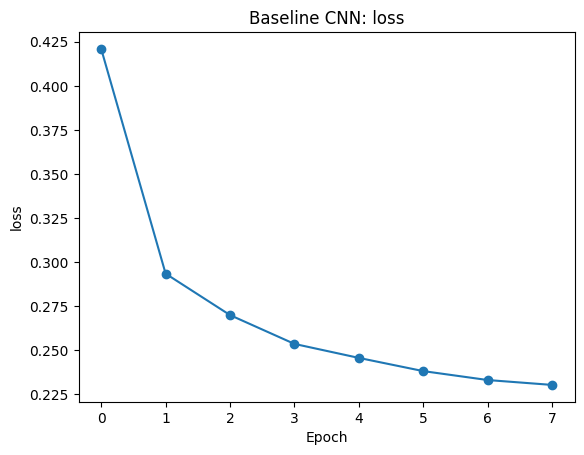

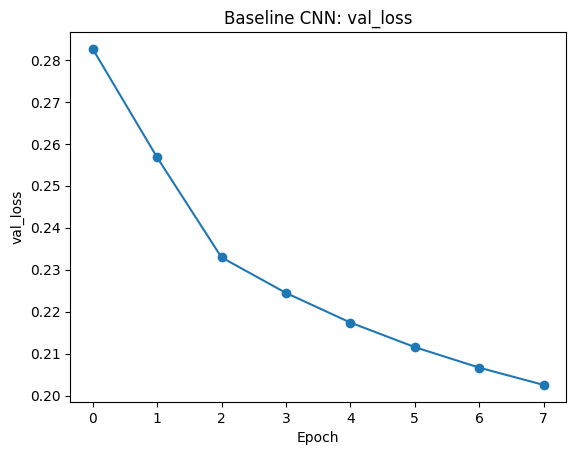

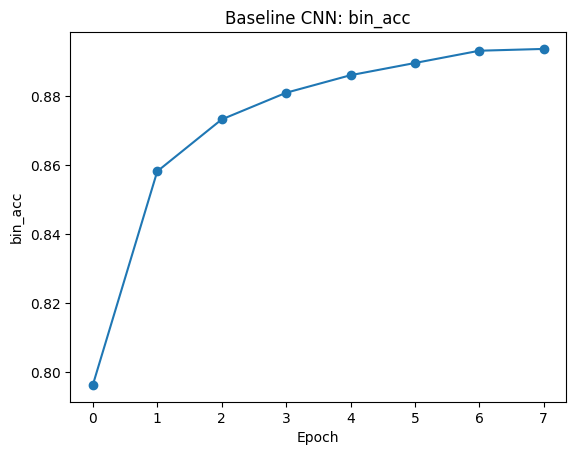

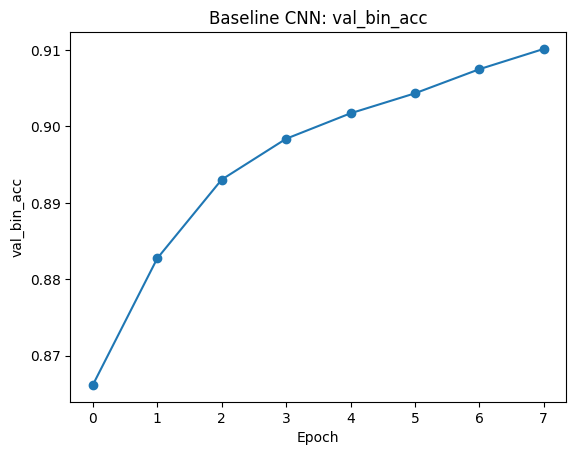

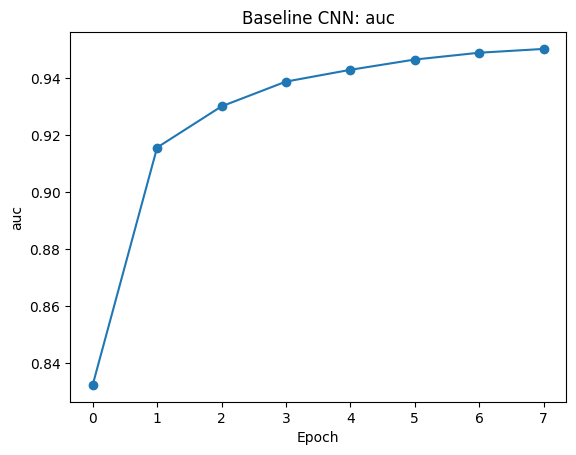

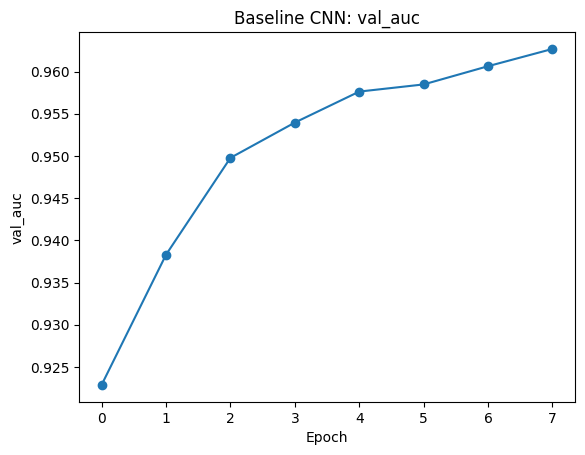

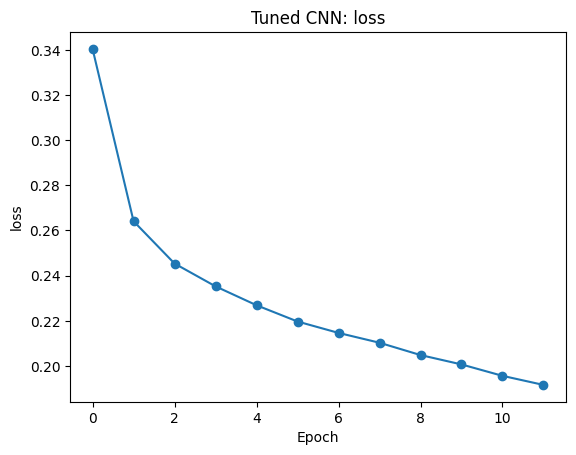

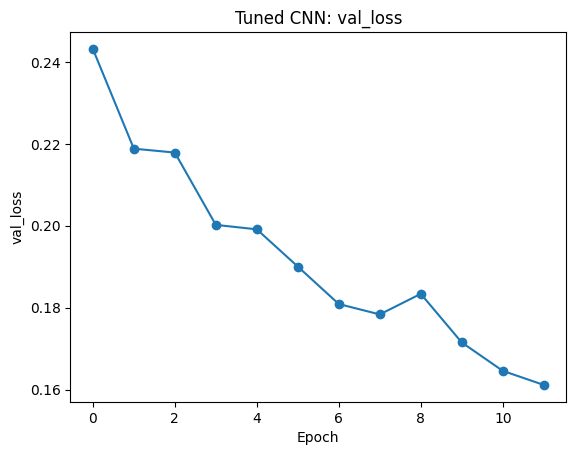

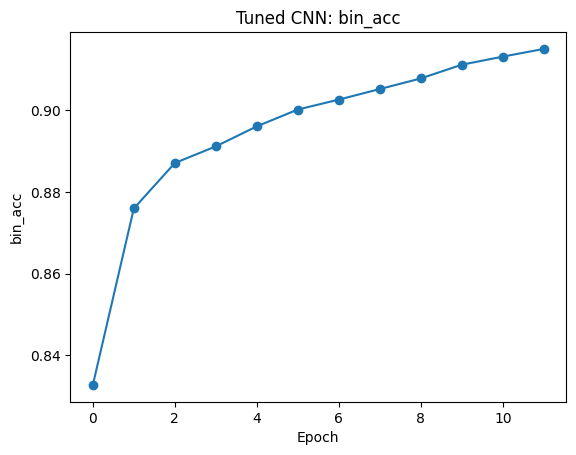

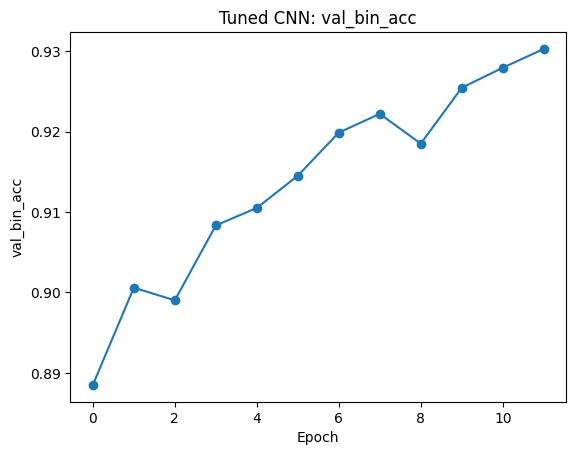

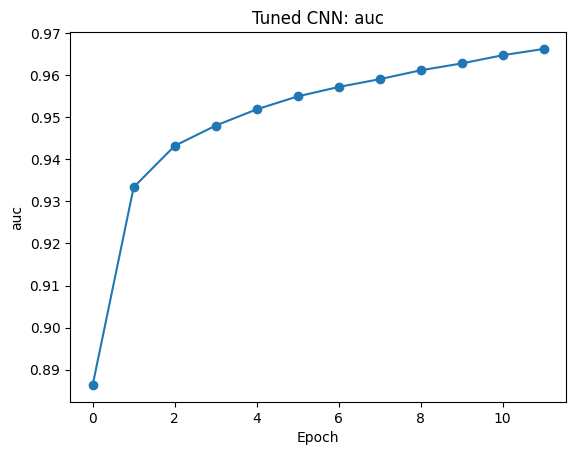

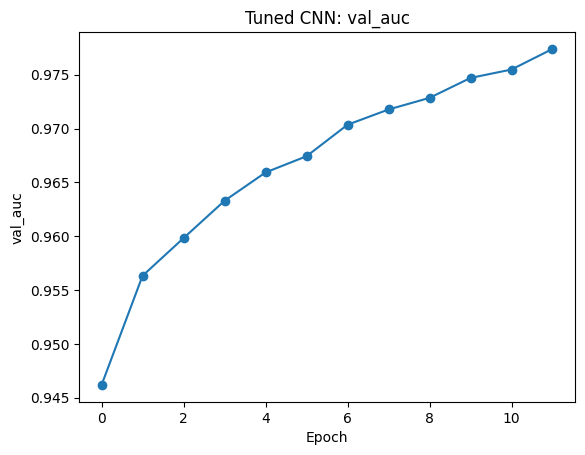

In [58]:
import matplotlib.pyplot as plt

def plot_history(history, title_prefix="Model"):
    hist = history.history
    for key in ["loss", "val_loss", "bin_acc", "val_bin_acc", "auc", "val_auc"]:
        if key in hist:
            plt.figure()
            plt.plot(hist[key], marker="o")
            plt.title(f"{title_prefix}: {key}")
            plt.xlabel("Epoch")
            plt.ylabel(key)
            plt.show()

plot_history(history_start, "Baseline CNN")
plot_history(history_tuned, "Tuned CNN")


<b>Overall Evaluation</b>
Training results show a clear decrease in loss and corresponding increases in binary accuracy and AUC, which indicates effective learning and stable convergence. The tuned CNN further improves performance without evidence of overfitting.

The model successfully recognizes all stations that have positive examples in the dataset, with non-zero recall for 14 of 15 labels. One station exhibits zero recall due to a lack of positive samples, reflecting a data imbalance rather than a failure of the model.